# Data Science Research Capstone & Whitepaper
## Financial Transaction Fraud Risk & Behavioral Pattern Analysis

**Author:** Amit Singh Bhadouriya  
**Project:** Data Science Research Capstone  

This notebook reproduces the end-to-end data pipeline, statistical hypothesis testing (Mann–Whitney U), predictive fraud classification (Logistic Regression, Random Forest), unsupervised customer clustering (K-Means), and behavioral risk visualization.

In [1]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, roc_auc_score, silhouette_score

# Prevent KMeans memory leak UserWarning on Windows with MKL
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
%matplotlib inline

In [2]:
# Robust dataset resolution whether running from notebooks/ or workspace root
candidates = [
    Path('../data/capstone_demo_dataset.csv'),
    Path('data/capstone_demo_dataset.csv'),
    Path('data_science_capstone_whitepaper/data/capstone_demo_dataset.csv'),
    Path('capstone_demo_dataset.csv')
]

data_path = None
for p in candidates:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not locate capstone_demo_dataset.csv in expected paths.")

print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)
print(f"Total records: {len(df)} | Columns: {len(df.columns)}")
df.head()

Loading dataset from: ..\data\capstone_demo_dataset.csv
Total records: 120 | Columns: 14


,index,transaction_id,customer_id,transaction_date,transaction_time,amount,merchant_category,payment_method,location,device_type,is_fraud,previous_transactions,account_age_days,failed_attempts
0,0,TXN0001,CUST1021,2026-08-04,07:47:00,10387.51,Grocery,UPI,Jaipur,Tablet,0,36,531,1
1,1,TXN0002,CUST1029,2026-08-18,09:37:00,7974.60,Electronics,Card,Mumbai,Tablet,0,55,95,0
2,2,TXN0003,CUST1020,2026-08-01,13:45:00,10961.22,Food,Wallet,Delhi,Mobile,0,70,889,1
3,3,TXN0004,CUST1023,2026-08-14,17:17:00,14287.51,Electronics,UPI,Gwalior,Mobile,0,20,470,2
4,4,TXN0005,CUST1012,2026-08-28,18:38:00,7610.22,Food,UPI,Gwalior,Mobile,0,34,118,5


In [3]:
# Timestamp parsing and temporal feature extraction
df['timestamp'] = pd.to_datetime(df['transaction_date'] + ' ' + df['transaction_time'], errors='coerce')
df = df.dropna(subset=['timestamp', 'amount', 'is_fraud']).copy()
df['hour'] = df['timestamp'].dt.hour
df['is_night'] = ((df['hour'] < 6) | (df['hour'] >= 23)).astype(int)

fraud_count = int(df['is_fraud'].sum())
fraud_pct = df['is_fraud'].mean() * 100
print(f"Cleaned dataset size: {len(df)}")
print(f"Fraudulent transactions: {fraud_count} ({fraud_pct:.2f}%)")
df[['amount', 'previous_transactions', 'account_age_days', 'failed_attempts', 'hour', 'is_fraud']].describe()

Cleaned dataset size: 120
Fraudulent transactions: 8 (6.67%)


,amount,previous_transactions,account_age_days,failed_attempts,hour,is_fraud
count,120.00000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,8879.23000,41.283333,769.250000,2.658333,14.883333,0.066667
std,4572.50179,22.009617,438.282597,2.027110,5.414241,0.250490
min,150.00000,1.000000,36.000000,0.000000,0.000000,0.000000
25%,6414.34000,21.000000,439.500000,1.000000,11.000000,0.000000
50%,8381.55500,39.500000,770.000000,2.500000,16.000000,0.000000
75%,10858.58250,61.000000,1163.500000,5.000000,19.250000,0.000000
max,25019.97000,80.000000,1476.000000,8.000000,23.000000,1.000000


In [4]:
# Non-parametric Mann-Whitney U tests for Amount and Failed Attempts
fraud = df.loc[df['is_fraud'] == 1]
normal = df.loc[df['is_fraud'] == 0]

u_amt, p_amt = mannwhitneyu(fraud['amount'], normal['amount'], alternative='two-sided')
u_fail, p_fail = mannwhitneyu(fraud['failed_attempts'], normal['failed_attempts'], alternative='two-sided')

print("=== Statistical Hypothesis Testing (Mann-Whitney U) ===")
print(f"1. Transaction Amount: U = {u_amt}, p-value = {p_amt:.4e}")
print(f"   - Fraud median: {fraud['amount'].median():.2f} vs Normal median: {normal['amount'].median():.2f}")
print(f"2. Failed Attempts:   U = {u_fail}, p-value = {p_fail:.4e}")
print(f"   - Fraud median: {fraud['failed_attempts'].median():.2f} vs Normal median: {normal['failed_attempts'].median():.2f}")

=== Statistical Hypothesis Testing (Mann-Whitney U) ===
1. Transaction Amount: U = 894.0, p-value = 2.7728e-06
   - Fraud median: 20249.33 vs Normal median: 8017.57
2. Failed Attempts:   U = 762.5, p-value = 7.9823e-04
   - Fraud median: 5.50 vs Normal median: 2.00


In [5]:
features = ['amount', 'previous_transactions', 'account_age_days', 'failed_attempts', 'hour']
X = df[features]
y = df['is_fraud'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

models = {
    'Logistic Regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight='balanced', random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n==================== {name} ====================")
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, preds, zero_division=0))


==================== Logistic Regression ====================
ROC-AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        28
           1       0.50      1.00      0.67         2

    accuracy                           0.93        30
   macro avg       0.75      0.96      0.81        30
weighted avg       0.97      0.93      0.94        30




==================== Random Forest ====================
ROC-AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00         2

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:
# K-Means clustering with standardized features
scaler = StandardScaler()
Z = scaler.fit_transform(df[features])

km = KMeans(n_clusters=3, n_init=20, random_state=42)
df['cluster'] = km.fit_predict(Z)
sil = silhouette_score(Z, df['cluster'])

print(f"K-Means Silhouette Score (k=3): {sil:.4f}")
print("\nCluster Profile Summary:")
cluster_summary = df.groupby('cluster').agg(
    transactions=('transaction_id', 'count'),
    fraud_rate=('is_fraud', 'mean'),
    avg_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    avg_failed=('failed_attempts', 'mean')
).reset_index()
cluster_summary

K-Means Silhouette Score (k=3): 0.1849

Cluster Profile Summary:


,cluster,transactions,fraud_rate,avg_amount,median_amount,avg_failed
0,0,9,0.777778,19570.140000,18521.02,5.666667
1,1,63,0.015873,7995.106349,8060.54,2.555556
2,2,48,0.000000,8035.096667,7764.58,2.229167


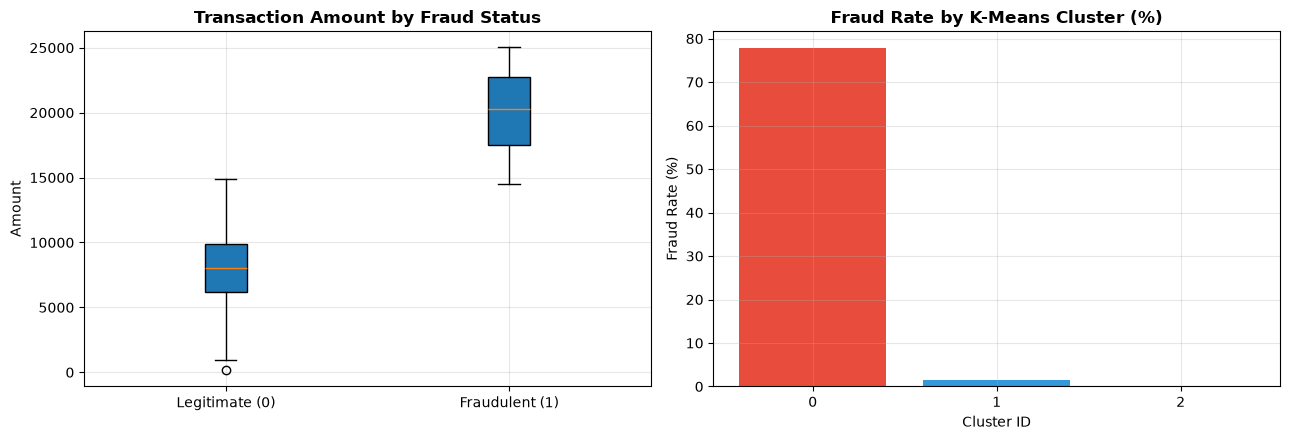

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Transaction Amount by Fraud Status
fraud_amounts = [df.loc[df['is_fraud'] == 0, 'amount'], df.loc[df['is_fraud'] == 1, 'amount']]
axes[0].boxplot(fraud_amounts, tick_labels=['Legitimate (0)', 'Fraudulent (1)'], patch_artist=True)
axes[0].set_title('Transaction Amount by Fraud Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount')
axes[0].grid(True, alpha=0.3)

# Plot 2: Fraud Rate by Cluster
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[1].bar(cluster_summary['cluster'].astype(str), cluster_summary['fraud_rate'] * 100, color=colors[:len(cluster_summary)])
axes[1].set_title('Fraud Rate by K-Means Cluster (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()